<img src="https://data-analytics-fullstack-assets.s3.eu-west-3.amazonaws.com/M05-Exploratory_Data_Analysis/M03-D05-WildWatch.png" />

# WildWatch sleep pattern analysis 🦊

You work as a AI analyst at **WildWatch Research Institute**, a conservation organization that studies animal behavior across different ecosystems.

The behavioral ecology team has collected sleep data from 83 mammal species. They need a clear summary of how mammals sleep, how much variation exists between species, and which animals show unusual patterns. Your work feeds into a presentation at the International Wildlife Conservation Summit next month.

The dataset `msleep.csv` contains the columns below.

| Column | Description |
|---|---|
| `name` | Common name of the mammal |
| `vore` | Diet type (carnivore, herbivore, omnivore, insectivore) |
| `sleep_total` | Total hours of sleep per day |
| `sleep_rem` | REM sleep hours per day |
| `brainwt` | Brain weight in kilograms |
| `bodywt` | Body weight in kilograms |

<Note type="important">

The dataset `msleep.csv` is available in the resources section.

</Note>

## Setup

### Instructions

In the next code cell:

1. Import `numpy` as `np` and `pandas` as `pd`.
2. Import the `stats` submodule from `scipy`: `from scipy import stats`.
3. Import `matplotlib.pyplot` as `plt` and `seaborn` as `sns`.
4. Set the seaborn theme to a clean white grid: `sns.set_theme(style="whitegrid")`.
5. Load the dataset with `df = pd.read_csv('msleep.csv')`.
6. As the last line, write `df.head()` (no `print(...)`) so Jupyter renders the first five rows as a table.

<Note type='tip'>
**Why set a seaborn theme?** `sns.set_theme(style="whitegrid")` configures the look of every chart in the notebook in one line. You stop fighting Matplotlib defaults and your charts gain a consistent, presentation-ready style.
</Note>


In [1]:
# your code here
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv("src/msleep.csv")
df.head()

,name,genus,vore,order,conservation,sleep_total,sleep_rem,sleep_cycle,awake,brainwt,bodywt
0,African elephant,Afr,herbivore,Proboscidea,vu,3.3,0.5,NaN,20.7,5.1600,6654.000
1,Asiatic elephant,Asi,herbivore,Proboscidea,en,3.9,0.6,NaN,20.1,4.6000,2547.000
2,Big brown bat,Big,insectivore,Chiroptera,lc,19.7,3.9,0.13,4.3,0.0003,0.023
3,Bottle-nosed dolphin,Bot,carnivore,Cetacea,lc,5.2,NaN,0.90,18.8,1.3200,173.500
4,Brazilian tapir,Bra,herbivore,Perissodactyla,vu,4.4,1.0,0.90,19.6,0.1690,160.000


## Task 1: Typical sleep duration

The team needs a single number that describes a typical mammal's sleep. You learned in the lecture that the mean, the median, and the mode each tell a different story, and that the gap between the mean and the median is the fingerprint of skew.

### Instructions

This task uses **two code cells**.

**First code cell**, the three statistics and the gap:

1. Compute the mean of the `sleep_total` column with `df['sleep_total'].mean()` and store it in `sleep_mean`.
2. Compute the median with `.median()` and store it in `sleep_median`.
3. Compute the mode with `.mode()` and store the result in `sleep_modes`. Pandas returns a Series because there can be more than one mode. Take the first one with `sleep_mode = sleep_modes[0]`.
4. Print the three values using f-strings with two decimal places, for example `print(f"Mean   : {sleep_mean:.2f} hours")`. Repeat for median and mode.
5. Compute `gap = sleep_mean - sleep_median` and `gap_percent = gap / sleep_median * 100`. Print both with f-strings, for example `print(f"\nGap between mean and median: {gap:.2f} hours ({gap_percent:.1f}%)")`.

**Second code cell**, the histogram with two reference lines:

1. Open a figure with `fig, ax = plt.subplots(figsize=(10, 5))`. The `ax` object is the chart area you draw on.
2. Draw the histogram with `sns.histplot(x=df['sleep_total'], bins=20, color="#FE0162", alpha=0.7, ax=ax)`. Always pass `ax=ax` so seaborn draws on the figure you opened.
3. Add a dashed vertical line at the mean: `ax.axvline(sleep_mean, color="#0B155B", linestyle="--", linewidth=2)`.
4. Add a small text label next to the mean line: `ax.text(sleep_mean, 1, f"Mean = {sleep_mean:.2f}", color="#0B155B")`. The `1` is the y-coordinate of the label.
5. Add a dotted vertical line at the median: `ax.axvline(sleep_median, color="green", linestyle=":", linewidth=2)`, then `ax.text(sleep_median, 3, f"Median = {sleep_median:.2f}", color="green")`.
6. Set the title and the axis labels with `ax.set_title(...)`, `ax.set_xlabel(...)`, `ax.set_ylabel(...)`.
7. Finish with `plt.tight_layout()` and `plt.show()`.

<Note type='tip'>
**Mode on continuous data.** The mode rarely matches the median or the mean on continuous variables like sleep hours, because exact ties are uncommon. It still gives you the most frequent recorded value, which can be useful when readings are rounded.
</Note>


In [ ]:
# your code here
sleep_mean = df["sleep_total"].mean()
sleep_median = df["sleep_total"].median()
sleep_mode = df["sleep_total"].mode()[0]

print(f"Mean: {sleep_mean:.2f}")
print(f"Median: {sleep_median:.2f}")
print(f"Mode: {sleep_mode:.2f}")

print("----------")
gap = sleep_mean - sleep_median
gap_percent = (gap / sleep_mean) * 100
print(f"Gap: {gap:.2f}")
print(f"Gap Percent: {gap_percent:.1f}%")

Mean: 10.68
Median: 10.40
Mode: 12.50
----------
Gap: 0.28
Gap Percent: 2.6%


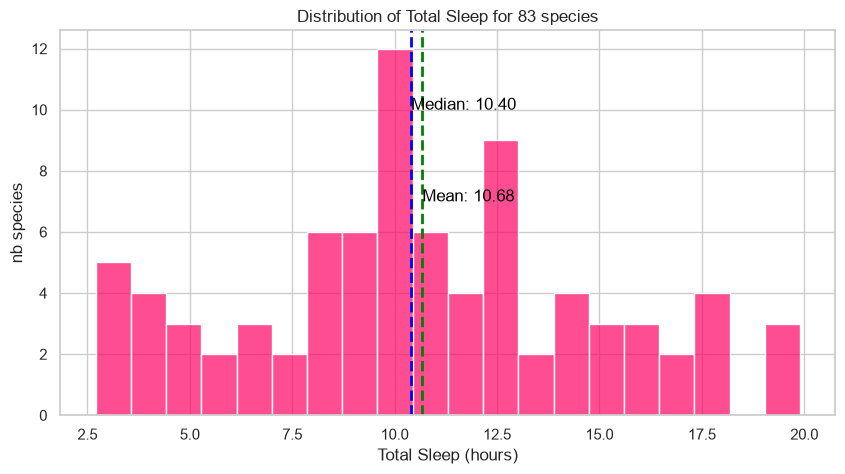

In [21]:
# your code here
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["sleep_total"], bins=20, color="#FE0162", alpha=0.7, ax=ax)
ax.axvline(sleep_mean, color="green", linestyle="--", linewidth=2)
ax.text(sleep_mean, 7, f"Mean: {sleep_mean:.2f}", color="black")
ax.axvline(sleep_median, color="blue", linestyle="--", linewidth=2)
ax.text(sleep_median, 10, f"Median: {sleep_median:.2f}", color="black")
ax.set_title("Distribution of Total Sleep for 83 species")
ax.set_xlabel("Total Sleep (hours)")
ax.set_ylabel("nb species")

plt.show()

## Task 2: Spread in body weight

The team wants to know how much body sizes vary across species. The lecture taught you that the variance measures spread in squared units, and the standard deviation brings the value back to the original units. You report numbers in kilograms, so the standard deviation is the measure you communicate.

### Instructions

In the next code cell:

1. Compute the mean of the `bodywt` column with `df['bodywt'].mean()` and store it in `bodywt_mean`.
2. Compute the variance with `df['bodywt'].var()` and store it in `bodywt_variance`.
3. Compute the standard deviation with `df['bodywt'].std()` and store it in `bodywt_std`.
4. Print the three values with two decimal places. Use clear unit labels in the strings: `kg` for the mean and the standard deviation, `kg^2` for the variance.
5. Compute the ratio of the standard deviation to the mean: `ratio = bodywt_std / bodywt_mean`. Print it with two decimals. A ratio close to 1 (or above) is a strong signal of skew.

<Note type='tip'>
**Why squared units for the variance?** Variance is the average of squared deviations, so its unit is the unit of the data squared. The standard deviation is the square root of the variance, which puts it back in the original unit (kilograms here). That is why the team reports the standard deviation, not the variance.
</Note>


In [25]:
# your code here
bodywt = df["bodywt"].mean()
bodywt_variance = df["bodywt"].var()
bodywt_std = df["bodywt"].std()

print(f"Mean: {bodywt:.2f} kg")
print(f"Variance: {bodywt_variance:.2f} kg^2")
print(f"Standard Deviation: {bodywt_std:.2f} kg")
print("----")
print(f"ratio: {bodywt_std/bodywt:.2f}")

Mean: 183.87 kg
Variance: 618765.12 kg^2
Standard Deviation: 786.62 kg
----
ratio: 4.28


## Task 3: Detect outlier species with the 3-sigma rule

The lecture introduced a simple rule: any value more than 3 standard deviations from the mean is a possible outlier. You will apply this rule to `sleep_total` to find species with unusual sleep behavior.

### Instructions

In the next code cell:

1. Compute and store `sleep_mean = df['sleep_total'].mean()` and `sleep_std = df['sleep_total'].std()`.
2. Build the bounds:
   - `lower_bound = sleep_mean - 3 * sleep_std`.
   - `upper_bound = sleep_mean + 3 * sleep_std`.
3. Print the four numbers (mean, std, lower bound, upper bound) with two decimal places.
4. Build two boolean masks, one per side of the distribution:
   - `below_mask = df['sleep_total'] < lower_bound`.
   - `above_mask = df['sleep_total'] > upper_bound`.
5. Combine them with the bitwise OR operator: `outlier_mask = below_mask | above_mask`.
6. Filter the DataFrame: `outliers = df[outlier_mask]`.
7. Print the count of flagged species: `print(f"\nNumber of outlier species: {len(outliers)}")`.
8. Print the relevant columns of the flagged rows: `print(outliers[['name', 'sleep_total']])`.

<Note type='tip'>
**Pandas uses `|` and `&`, not `or` and `and`.** Boolean masks are NumPy arrays of `True`/`False`, and Python's `or`/`and` do not understand arrays. Always use the bitwise operators `|` (or) and `&` (and), and wrap each condition in parentheses when combining them.
</Note>


In [29]:
# your code
sleep_mean = df['sleep_total'].mean()
sleep_std = df['sleep_total'].std()

lower_bound = sleep_mean - 3 * sleep_std
upper_bound = sleep_mean + 3 * sleep_std

print(f"mean: {sleep_mean:.2f}")
print(f"std: {sleep_std:.2f}")
print(f"lower bound: {lower_bound:.2f}")
print(f"upper bound: {upper_bound:.2f}")
print("----")
below_mask = df['sleep_total'] < lower_bound
above_mask = df['sleep_total'] > upper_bound

outliers_mask = below_mask | above_mask
outliers = df[outliers_mask]
print(f"\n nb of outliers species: {len(outliers)}")
print(outliers[['name', 'sleep_total']])


mean: 10.68
std: 4.35
lower bound: -2.36
upper bound: 23.72
----

 nb of outliers species: 0
Empty DataFrame
Columns: [name, sleep_total]
Index: []


## Task 4: Sleep by diet group

Different diets bring different energy needs. The team wants to know if carnivores, herbivores, omnivores, and insectivores sleep differently.

### Instructions

In the next code cell:

1. Group the DataFrame by `vore` and pick the `sleep_total` column: `grouped = df.groupby('vore')['sleep_total']`. The result is a `SeriesGroupBy` object: it remembers the grouping but has not computed anything yet.
2. Apply four aggregations at once with `.agg([...])`. Pass a list of strings naming the aggregations:
   ```python
   stats_per_diet = grouped.agg(['mean', 'median', 'std', 'count'])
   ```
   The result is a DataFrame with one row per diet group and one column per statistic.
3. Round the table for readable output: `stats_per_diet = stats_per_diet.round(2)`.
4. Print the table: `print(stats_per_diet)`.

<Note type='tip'>
**`agg` with a list does several aggregations in one pass.** Without `.agg(list)` you would need four separate `.mean()`, `.median()`, `.std()`, `.count()` calls, then merge them. The list form does the work in a single call and produces a clean table.
</Note>


In [33]:
# your code here
grouped = df.groupby("vore")['sleep_total']
stats_per_diet = grouped.agg(['mean', 'median', 'std', 'count'])
stats_per_diet = stats_per_diet.sort_values(by='mean', ascending=False).round(2)
print(stats_per_diet)

              mean  median   std  count
vore                                   
insectivore  14.09   13.85  5.12      8
omnivore     11.10   10.10  2.70     26
carnivore    10.88   11.05  4.01     20
herbivore     9.21    8.40  5.06     29


## Task 5: Build a reusable summary function

New data arrives every few weeks. The team wants a single function that returns the core statistics for any numeric column. You will build that tool now.


### Instructions

This task uses **two code cells**.

**First code cell**, define the function:

1. Start with `def summary_statistics(dataframe, column_name):`.
2. Pull the column out: `column = dataframe[column_name]`.
3. Drop missing values: `clean_column = column.dropna()`. Without this step, statistics like the mean would skip `NaN` values silently, but `len(...)` would still count them, leading to a wrong `count`.
4. Compute the mode and pick the first value (the mode can return more than one): `modes = clean_column.mode()`, then `first_mode = modes[0]`.
5. Build a dictionary called `stats_dict` and assign one statistic per key:
   - `stats_dict['mean'] = clean_column.mean()`.
   - `stats_dict['median'] = clean_column.median()`.
   - `stats_dict['mode'] = first_mode`.
   - `stats_dict['variance'] = clean_column.var()`.
   - `stats_dict['std'] = clean_column.std()`.
   - `stats_dict['min'] = clean_column.min()`.
   - `stats_dict['max'] = clean_column.max()`.
   - `stats_dict['count'] = len(clean_column)`.
6. Return the dictionary: `return stats_dict`.

**Second code cell**, apply the function to three columns and build the summary table:

1. Create an empty dictionary: `results = {}`.
2. Call the function three times and store each return value under a key with the column name:
   - `results['sleep_total'] = summary_statistics(df, 'sleep_total')`.
   - `results['sleep_rem'] = summary_statistics(df, 'sleep_rem')`.
   - `results['bodywt'] = summary_statistics(df, 'bodywt')`.
3. Convert the nested dictionary to a DataFrame: `summary_table = pd.DataFrame(results)`. Each outer key becomes a column, and the inner keys (`mean`, `median`, ...) become the row index.
4. Round to two decimals: `summary_table = summary_table.round(2)`.
5. Print the result: `print(summary_table)`.

<Note type='tip'>
**Drop missing values before counting.** Real datasets have gaps. If you call `column.mean()` on a column with `NaN` values, pandas skips them automatically. But `len(column)` does not. Calling `.dropna()` first makes every statistic in your function consistent with the same set of rows.
</Note>


In [35]:
# your code here
def summary_statistics(df, column_name):
    column = df[column_name]
    clean_column = column.dropna() 
    modes = clean_column.mode()
    first_mode = modes[0]
    stats_dict = {
        "mean": clean_column.mean(),
        "median": clean_column.median(),
        "mode": first_mode,
        "std": clean_column.std(),
        "count": clean_column.count(),
        "min": clean_column.min(),
        "max": clean_column.max(),
        "variance": clean_column.var()
    }
    return stats_dict

In [36]:
# your code here
results = {}
results['sleep_total'] = summary_statistics(df, 'sleep_total')
results['sleep_rem'] = summary_statistics(df, 'sleep_rem')
results['bodywt'] = summary_statistics(df, 'bodywt')

summary_table = pd.DataFrame(results)
summary_table = summary_table.round(2)

print(summary_table)


          sleep_total  sleep_rem     bodywt
mean            10.68       1.97     183.87
median          10.40       1.90       4.50
mode            12.50       0.60      50.00
std              4.35       1.30     786.62
count           83.00      59.00      83.00
min              2.70       0.10       0.00
max             19.90       6.60    6654.00
variance        18.90       1.70  618765.12
